# 기계학습 실습 10: LSTM을 이용한 문자 단위 다음 글자 예측

## 학습 목표
- 문장을 문자 단위 sequence 데이터로 바꾼다.
- one-hot encoding으로 문자를 neural network 입력으로 변환한다.
- LSTM이 앞의 문자 흐름을 이용해 다음 문자를 예측하는 방식을 실습한다.

## 직접 바꿔볼 것
- `source_text` 문장
- `N_TIMESTEPS` 입력 길이
- `HIDDEN_SIZE` LSTM neuron 수
- `EPOCHS` 학습 횟수


## 1. 패키지 로드

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed
from tensorflow.keras.utils import to_categorical

np.random.seed(0)
tf.random.set_seed(0)

## 2. 사용할 문장 설정
아래 `source_text`만 바꾸면 다른 문장으로도 같은 코드가 동작한다. 단, 너무 짧은 문장은 sequence sample이 거의 만들어지지 않으므로 최소 수십 글자 이상을 권장한다.

In [3]:
source_text = """
The quick brown fox jumps over the lazy dog. Pack my box with five dozen liquor jugs.
Machine learning models improve when they see enough examples, but they still need
clear data, careful evaluation, and a question worth answering.
"""

# 줄바꿈과 여러 공백을 하나의 공백으로 정리한다.
sentence = ' '.join(source_text.lower().split())

print(sentence)
print('Number of characters:', len(sentence))

the quick brown fox jumps over the lazy dog. pack my box with five dozen liquor jugs. machine learning models improve when they see enough examples, but they still need clear data, careful evaluation, and a question worth answering.
Number of characters: 232


## 3. 문자 사전 만들기
컴퓨터는 문자를 직접 계산할 수 없으므로, 각 문자를 정수 index로 바꾸고 다시 one-hot vector로 변환한다.

In [4]:
char_set = sorted(set(sentence))
char_to_idx = {ch: i for i, ch in enumerate(char_set)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

num_classes = len(char_set)
print('Characters:', ''.join(char_set))
print('Number of unique characters:', num_classes)

Characters:  ,.abcdefghijklmnopqrstuvwxyz
Number of unique characters: 29


## 4. Sequence 데이터 만들기
입력 `X`는 길이 `N_TIMESTEPS`의 문자열이고, 목표값 `Y`는 같은 위치에서 한 글자씩 뒤로 밀린 문자열이다. 예를 들어 `machine`에서 입력이 `mach`이면 목표값은 `achi`가 된다.

In [5]:
N_TIMESTEPS = 40

if len(sentence) <= N_TIMESTEPS:
    N_TIMESTEPS = max(5, len(sentence) // 2)

sample_size = len(sentence) - N_TIMESTEPS
if sample_size <= 0:
    raise ValueError('문장이 너무 짧습니다. source_text를 더 길게 바꾸세요.')

X_seqs = np.zeros((sample_size, N_TIMESTEPS), dtype='int32')
Y_seqs = np.zeros((sample_size, N_TIMESTEPS), dtype='int32')

for i in range(sample_size):
    x_str = sentence[i:i + N_TIMESTEPS]
    y_str = sentence[i + 1:i + N_TIMESTEPS + 1]
    X_seqs[i] = [char_to_idx[ch] for ch in x_str]
    Y_seqs[i] = [char_to_idx[ch] for ch in y_str]

x_onehot = to_categorical(X_seqs, num_classes=num_classes)
y_onehot = to_categorical(Y_seqs, num_classes=num_classes)

print('X_seqs:', X_seqs.shape)
print('x_onehot:', x_onehot.shape)
print('y_onehot:', y_onehot.shape)

X_seqs: (192, 40)
x_onehot: (192, 40, 29)
y_onehot: (192, 40, 29)


In [6]:
example_id = 0
print('Input :', ''.join(idx_to_char[i] for i in X_seqs[example_id]))
print('Target:', ''.join(idx_to_char[i] for i in Y_seqs[example_id]))

Input : the quick brown fox jumps over the lazy 
Target: he quick brown fox jumps over the lazy d


## 5. LSTM 모델 구성
`return_sequences=True`로 설정하면 각 시점마다 다음 문자를 예측한다. 따라서 출력 shape은 `(samples, timesteps, num_classes)`가 된다.

In [7]:
HIDDEN_SIZE = 100

model = Sequential([
    LSTM(HIDDEN_SIZE, input_shape=(N_TIMESTEPS, num_classes), return_sequences=True),
    TimeDistributed(Dense(num_classes, activation='softmax'))
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

model.summary()

E0000 00:00:1782035288.109778 2061322 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782035288.110327 2061950 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782035288.129384 2061322 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a la

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 100)        │        52,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 40, 29)         │         2,929 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,929 (214.57 KB)

 Trainable params: 54,929 (214.57 KB)

 Non-trainable params: 0 (0.00 B)

## 6. 모델 학습

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.1299 - loss: 3.1710
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1755 - loss: 2.9798
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1816 - loss: 2.8687
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2327 - loss: 2.6690
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2992 - loss: 2.3480
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4289 - loss: 1.9671
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5949 - loss: 1.5305
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7319 - loss: 1.0813
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8418 - loss: 0.7428
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9053 - loss: 0.4955
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9335 - loss: 0.3377
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9457 - lo

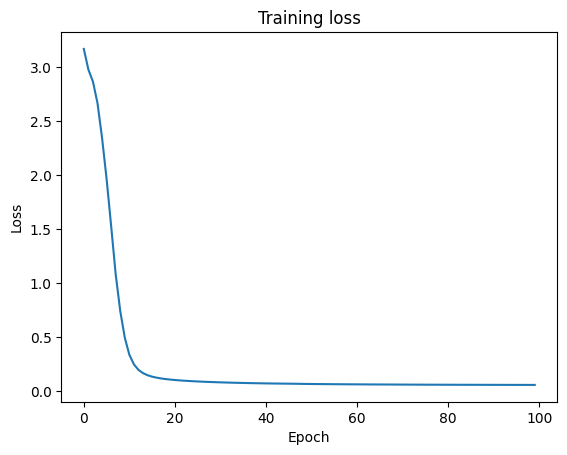

In [8]:
EPOCHS = 100

history = model.fit(x_onehot, y_onehot, epochs=EPOCHS, verbose=1)

plt.plot(history.history['loss'])
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 7. 학습 결과 확인
첫 번째 sequence에 대해 모델이 예측한 다음 문자들을 실제 목표 문자열과 비교한다.

In [9]:
pred_prob = model.predict(x_onehot[:1], verbose=0)
pred_idx = np.argmax(pred_prob[0], axis=1)

input_text = ''.join(idx_to_char[i] for i in X_seqs[0])
target_text = ''.join(idx_to_char[i] for i in Y_seqs[0])
pred_text = ''.join(idx_to_char[i] for i in pred_idx)

print('Input :', input_text)
print('Target:', target_text)
print('Pred  :', pred_text)

Input : the quick brown fox jumps over the lazy 
Target: he quick brown fox jumps over the lazy d
Pred  : heyquick brown fox jumps over the lazy d


## 8. 짧은 문장 생성 함수
시작 문자열을 넣으면 모델이 한 글자씩 이어서 예측한다. 학습 문장이 짧으므로 결과가 완벽한 문장이 되기보다는, 문자 패턴을 얼마나 익혔는지 확인하는 용도이다.

In [10]:
def generate_text(seed_text, n_chars=120):
    seed = ' '.join(seed_text.lower().split())
    if len(seed) < N_TIMESTEPS:
        seed = (sentence[:N_TIMESTEPS] + seed)[-N_TIMESTEPS:]
    else:
        seed = seed[-N_TIMESTEPS:]

    generated = seed
    for _ in range(n_chars):
        x = np.array([[char_to_idx.get(ch, 0) for ch in generated[-N_TIMESTEPS:]]])
        x = to_categorical(x, num_classes=num_classes)
        prob = model.predict(x, verbose=0)[0, -1]
        next_idx = int(np.argmax(prob))
        generated += idx_to_char[next_idx]
    return generated

print(generate_text('machine learning', n_chars=120))

fox jumps over the lazy machine learning models improve when they see enough examples, but they still need clear data, careful evaluation, and a question worth 


## 실습 과제
1. `source_text`를 다른 문장으로 바꾸고 그대로 실행해보라.
2. `N_TIMESTEPS`를 20, 40, 80으로 바꾸어 학습 난이도를 비교하라.
3. `HIDDEN_SIZE`와 `EPOCHS`를 조절해 생성 결과가 어떻게 바뀌는지 확인하라.